# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

145516.6158593842 warmte toegevoegd
40680.00000000001 warmte voor verdamping
107394.92764000002 warmte voor opwarmen
148074.92764000004 totale warmte


Text(0, 0.5, 'Temperatuur (°C)')

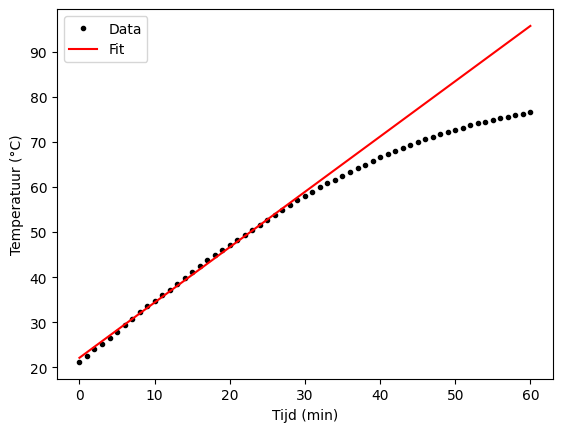

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = np.loadtxt('tempmetingen.csv', delimiter=';', skiprows=1)

m_verschil = (1292.9 - 1274.9)*1e-3  #kilogram
m_water = (1292.9 - 820.8)*1e-3 #kilogram
verdampingswarmte = 2260 * 1e3  #J/kg
m_water_gemiddeld = m_water - m_verschil/2
cwater = 4186  #J/kgK

def linear(x, a, b):
    return a * x + b

var, cov = curve_fit(linear, data[:32, 0], data[:32, 1])
x_test = np.linspace(0, 60, 100)

a = var[0]/60
Q = a * cwater * 3600 * m_water
Q_verdampt = verdampingswarmte * m_verschil
Q_warmte = m_water_gemiddeld * cwater * 55.4
print(f"{Q} warmte toegevoegd")
print(f"{Q_verdampt} warmte voor verdamping")
print(f"{Q_warmte} warmte voor opwarmen")
print(f"{Q_verdampt + Q_warmte} totale warmte")

plt.plot(data[:, 0], data[:, 1], 'k.', label='Data')
plt.plot(x_test, linear(x_test, *var), 'r-', label='Fit')
plt.legend()
plt.xlabel('Tijd (min)')
plt.ylabel('Temperatuur (°C)')

We zijn er bij deze simulatie vanuit gegaan dat water een constante verdampingswarmt heeft, deze verdandert echter met de temperatuur. Ook hebben we de gemiddelde massa genomen voor de interne warmte van het water. Als we deze twee bij elkaar optellen komen we ongeveer uit op de verwachte warmte toegevoegd vanuit de curvefit. Daarom trekken we de conclusie dat er inderdaad water is verdampt. Voor het verbeteren van het experiment kunnen we de warmteverliezen aan de omgeving ook meenemen in de berekeningen. Ook kunnen we dan de verdampingswarmte niet constant nemen en een nauwkeurigere conclusie trekken.